##  CROP BACKGROUND PIXELS TO HELP WITH SIM


#### Remove excess background pixels from stitched astrocyte segmentation maps to reduce image size while preserving the full astrocyte structure.

### Compute Astrocyte Foreground Bounds

Load each stitched astrocyte `.npy` file, identify all non-background pixels, compute the smallest bounding box that contains the astrocyte, and save the cropping bounds to a JSON file.

In [1]:
import numpy as np
import os
import json


input_dir_healthy = "Step_0_Stitched_NPYs"
bounds_dir = "Step_1_Cropping_Bounds"
os.makedirs(bounds_dir, exist_ok=True)

def load_npy(file_path):
    return np.load(file_path)

def get_foreground_bounds(mask):
    """Get the bounding box of the non-background regions."""
    foreground_pixels = np.argwhere(mask < 3)  # Ignore background (3)
    if len(foreground_pixels) == 0:
        raise ValueError("No astrocyte structure found!")
    min_y, min_x = foreground_pixels.min(axis=0)  
    max_y, max_x = foreground_pixels.max(axis=0) 
    return int(min_y), int(max_y), int(min_x), int(max_x)  # Convert np.int64 to int


bounds_dict = {} # Dictionary to store cropping bounds

# Process all healthy images
for filename in sorted(os.listdir(input_dir_healthy)):
    if filename.endswith(".npy"):
        file_path = os.path.join(input_dir_healthy, filename)
        healthy_mask = load_npy(file_path)

        print(f"Processing Healthy Astrocyte: {filename}")
        
        # Compute cropping bounds and convert to Python ints
        bounds = get_foreground_bounds(healthy_mask)
        bounds_dict[filename] = bounds  # Store bounds for later use

# Save bounds to JSON file
bounds_file = os.path.join(bounds_dir, "healthy_cropping_bounds.json")
with open(bounds_file, "w") as f:
    json.dump(bounds_dict, f, indent=4)  # Now serializable

print(f"\Saved cropping bounds for all healthy images to {bounds_file}")


Processing Healthy Astrocyte: Healthy_astro_1_stitched.npy
\Saved cropping bounds for all healthy images to Step_1_Cropping_Bounds/healthy_cropping_bounds.json


### Compute Fixed Square Cropping Bounds

Generate centered square cropping bounds around each astrocyte using a fixed crop size. This keeps all cropped images aligned to a consistent spatial size for later simulation steps.

In [2]:
import numpy as np
import os
import json

input_dir_healthy = "Step_0_Stitched_NPYs"
bounds_dir = "Step_1_Cropping_Bounds"
os.makedirs(bounds_dir, exist_ok=True)

fixed_square_size = 3670 # Fixed square size to fit all images

def load_npy(file_path):
    return np.load(file_path)

def get_centered_square_bounds(mask, square_size):
    """Compute a centered square cropping area based on the astrocyte's bounding box."""
    foreground_pixels = np.argwhere(mask < 3)  # Ignore background (3)
    if len(foreground_pixels) == 0:
        raise ValueError("No astrocyte structure found!")

    # Get bounding box of astrocyte
    min_y, min_x = foreground_pixels.min(axis=0)
    max_y, max_x = foreground_pixels.max(axis=0)

    # Compute astrocyte center
    center_y = (min_y + max_y) // 2
    center_x = (min_x + max_x) // 2

    # Calculate new square boundaries
    min_y = max(0, center_y - square_size // 2)
    max_y = min(mask.shape[0], min_y + square_size)

    min_x = max(0, center_x - square_size // 2)
    max_x = min(mask.shape[1], min_x + square_size)

    # Adjust min values if max values are clipped
    min_y = max(0, max_y - square_size)
    min_x = max(0, max_x - square_size)

    return int(min_y), int(max_y), int(min_x), int(max_x)

# Dictionary to store cropping bounds
bounds_dict = {}

# Process all healthy images
for filename in sorted(os.listdir(input_dir_healthy)):
    if filename.endswith(".npy"):
        file_path = os.path.join(input_dir_healthy, filename)
        healthy_mask = load_npy(file_path)

        print(f"Processing Healthy Astrocyte: {filename}")

        # Compute square cropping bounds and convert to Python ints
        bounds = get_centered_square_bounds(healthy_mask, fixed_square_size)
        bounds_dict[filename] = bounds  # Store bounds for later use

# Save bounds to JSON file
bounds_file = os.path.join(bounds_dir, "healthy_cropping_bounds.json")
with open(bounds_file, "w") as f:
    json.dump(bounds_dict, f, indent=4)  # Now serializable

print(f"\n Saved fixed square cropping bounds (3670x3670) for all healthy images to {bounds_file}")


Processing Healthy Astrocyte: Healthy_astro_1_stitched.npy

 Saved fixed square cropping bounds (3670x3670) for all healthy images to Step_1_Cropping_Bounds/healthy_cropping_bounds.json


### Crop Astrocyte Maps Using Saved Bounds

Load the saved cropping bounds, crop each stitched astrocyte segmentation map with a small padding margin, compare label pixel counts before and after cropping, save the cropped `.npy` files, and visualize the cropped result.


Processing Healthy Astrocyte: Healthy_astro_1_stitched.npy
**Before Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 1668352 pixels
Label 3: 15158142 pixels

**After Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 1668352 pixels
Label 3: 10993278 pixels
Cropped Healthy Astrocyte saved to: Step_1_Cropped_Healthy_NPYs/Healthy_astro_1_stitched.npy


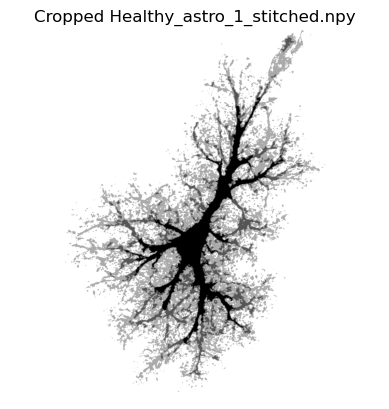

In [5]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt

input_dir_healthy = "Step_0_Stitched_NPYs"
output_dir_healthy = "Step_1_Cropped_Healthy_NPYs"
bounds_file = "Step_1_Cropping_Bounds/healthy_cropping_bounds.json"
os.makedirs(output_dir_healthy, exist_ok=True)

def load_npy(file_path):
    return np.load(file_path)

def crop_using_fixed_bounds(mask, fixed_bounds, padding=5):
    """Crop the image using predefined bounds to ensure alignment."""
    min_y, max_y, min_x, max_x = fixed_bounds
    min_y = max(0, min_y - padding)
    max_y = min(mask.shape[0], max_y + padding)
    min_x = max(0, min_x - padding)
    max_x = min(mask.shape[1], max_x + padding)
    return mask[min_y:max_y, min_x:max_x]

def print_label_pixel_counts(mask):
    """Print the count of each label in the mask."""
    unique_labels, counts = np.unique(mask, return_counts=True)
    label_counts = dict(zip(unique_labels, counts))
    print("\n **Pixel Count for Each Label:**")
    for label, count in label_counts.items():
        print(f"Label {label}: {count} pixels")
    return label_counts

def visualize_mask(mask, title="Cropped Astrocyte"):
    """Display the cropped image."""
    plt.imshow(mask, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()

# Load saved cropping bounds
with open(bounds_file, "r") as f:
    bounds_dict = json.load(f)

# Crop each healthy astrocyte
for filename, bounds in bounds_dict.items():
    file_path = os.path.join(input_dir_healthy, filename)

    print(f"\nProcessing Healthy Astrocyte: {filename}")

    # Load image
    healthy_mask = load_npy(file_path)

    # Print pixel counts before cropping
    print("**Before Cropping:**")
    label_counts_before = print_label_pixel_counts(healthy_mask)

    # Crop using stored bounds
    cropped_healthy = crop_using_fixed_bounds(healthy_mask, bounds, padding=5)

    # Print pixel counts after cropping
    print("")
    print("**After Cropping:**")
    label_counts_after = print_label_pixel_counts(cropped_healthy)

    # Save cropped healthy astrocyte
    output_path = os.path.join(output_dir_healthy, filename)
    np.save(output_path, cropped_healthy)
    print(f"Cropped Healthy Astrocyte saved to: {output_path}")

    # Visualize cropped image
    visualize_mask(cropped_healthy, title=f"Cropped {filename}")
